In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/notebooks'
os.chdir(project_path)

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

print("Loading data...")
train_df = pd.read_csv('../data/processed/train_augmented.csv')
test_df = pd.read_csv('../data/processed/test_original.csv')

X_train = train_df.drop('Exited', axis=1)
y_train = train_df['Exited']

X_test = test_df.drop('Exited', axis=1)
y_test = test_df['Exited']

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Loading data...
Training Data Shape: (12740, 14)
Testing Data Shape: (2000, 14)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics


print("\n Logistic Regression")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(metrics.classification_report(y_test, y_pred_lr))

print("\n Decision Tree")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_dt))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1593
           1       0.42      0.58      0.49       407

    accuracy                           0.75      2000
   macro avg       0.65      0.69      0.66      2000
weighted avg       0.79      0.75      0.77      2000


 Decision Tree
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1593
           1       0.44      0.60      0.51       407

    accuracy                           0.76      2000
   macro avg       0.66      0.70      0.67      2000
weighted avg       0.80      0.76      0.77      2000



In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("\n Random Forest")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_rf))

print("\n XGBoost")
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_xgb))

print("\n LightGBM")
lgbm = LGBMClassifier(verbose=-1, random_state=42)
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_lgbm))


 Random Forest
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1593
           1       0.58      0.60      0.59       407

    accuracy                           0.83      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.83      0.83      0.83      2000


 XGBoost
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1593
           1       0.61      0.58      0.60       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000


 LightGBM
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.64      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Summary Table:
                 Model    Recall   ROC-AUC  Accuracy  Precision  F1-Score
4             LightGBM  0.641278  0.848981    0.8335   0.582589  0.610526
1        Decision Tree  0.601966  0.702113    0.7615   0.437500  0.506722
2        Random Forest  0.597052  0.841504    0.8300   0.579952  0.588378
0  Logistic Regression  0.584767  0.763321    0.7535   0.423488  0.491228
3              XGBoost  0.579853  0.830397    0.8400   0.612987  0.595960


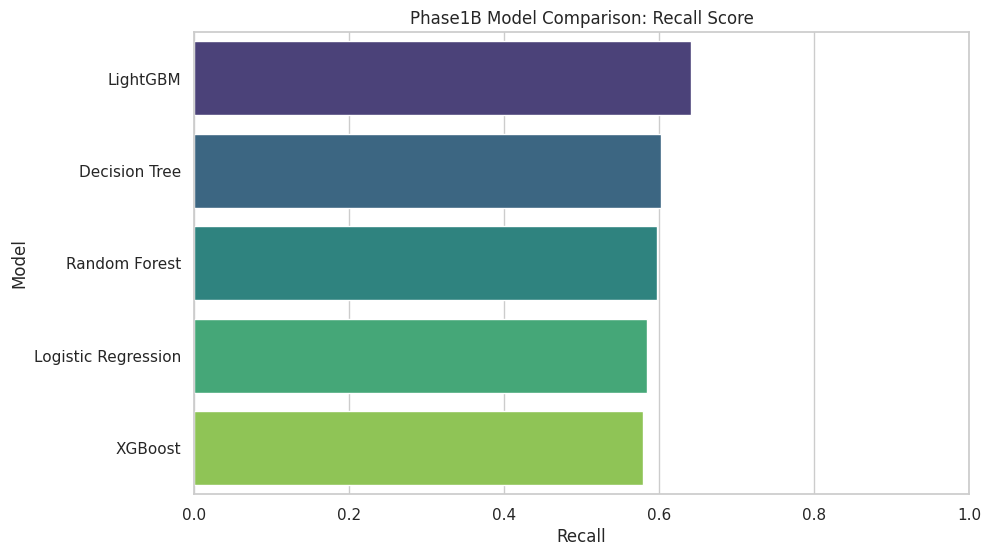

In [6]:
models_list = [
    ("Logistic Regression", lr, y_pred_lr),
    ("Decision Tree", dt, y_pred_dt),
    ("Random Forest", rf, y_pred_rf),
    ("XGBoost", xgb, y_pred_xgb),
    ("LightGBM", lgbm, y_pred_lgbm)
]

results = []

for name, model, preds in models_list:
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = preds

    results.append({
        "Model": name,
        "Recall": metrics.recall_score(y_test, preds),
        "ROC-AUC": metrics.roc_auc_score(y_test, probs),
        "Accuracy": metrics.accuracy_score(y_test, preds),
        "Precision": metrics.precision_score(y_test, preds),
        "F1-Score": metrics.f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
print("\nSummary Table:")
print(results_df)

results_df.to_csv('../results/tables/02_Model_Benchmarking_Phase1B_benchmark.csv', index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Recall', y='Model', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title("Phase1B Model Comparison: Recall Score")
plt.xlabel("Recall")
plt.xlim(0, 1)
plt.savefig('../results/figures/02_Model_Benchmarking_Phase1B_benchmark.png')
plt.show()

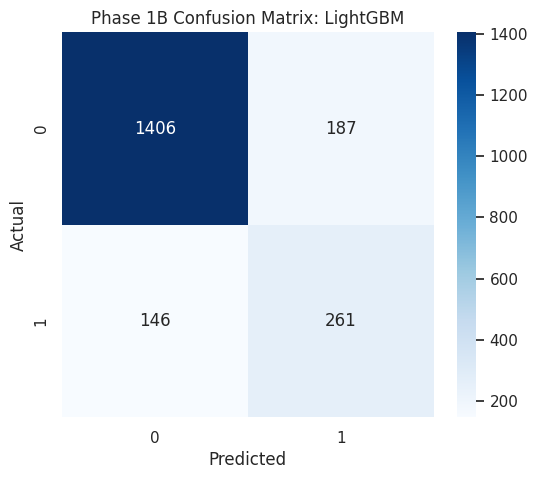

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Phase 1B Confusion Matrix: LightGBM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig('../results/figures/02_Model_Benchmarking_Phase1B_Confusion_Matrix_LightGBM.png')
plt.show()